## Where Do People Drink The Most Beer, Wine And Spirits?

<img src="https://s1.qwant.com/thumbr/0x0/3/f/a2d61eb9aa851a55e62456389bde7986e358da62a08b5c5ac98aaa851447dc/alcoholconsumption.gif?u=http%3A%2F%2F4.bp.blogspot.com%2F-0u5Sk_omAEE%2FTV3XZtyPQ1I%2FAAAAAAAAArc%2FyVlSiUp6aTU%2Fs1600%2Falcoholconsumption.gif&q=0&b=1&p=0&a=1">

The dataset for this analysis is from this post in [FiveThirtyEight](https://fivethirtyeight.com/features/dear-mona-followup-where-do-people-drink-the-most-beer-wine-and-spirits/)

Data: https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv

## Problem 1
Convert the following data into tidy format with the headers `country`, `drink` and `servings`. Drop the column `total_litres_of_pure_alcohol`

In [6]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv')

df=df.drop(columns=['total_litres_of_pure_alcohol'])

df.head()

tidy = df.melt(
    id_vars='country',
    var_name='drink',
    value_name='servings'
)

print(tidy.head())

       country          drink  servings
0  Afghanistan  beer_servings         0
1      Albania  beer_servings        89
2      Algeria  beer_servings        25
3      Andorra  beer_servings       245
4       Angola  beer_servings       217


## Problem 2
Remove `"_servings"` from the data in the tidy dataframe in Problem 1. Who drinks the most beer, wine and spirits? Create three categorical plots of your choice to illustrate the top 10 countries that drink the most wine, beer or spirits.

/tmp/ipykernel_4248/4019745669.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='servings', y='country', ax=ax, palette='viridis')
/tmp/ipykernel_4248/4019745669.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='servings', y='country', ax=ax, palette='viridis')
/tmp/ipykernel_4248/4019745669.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='servings', y='country', ax=ax, palette='viridis')


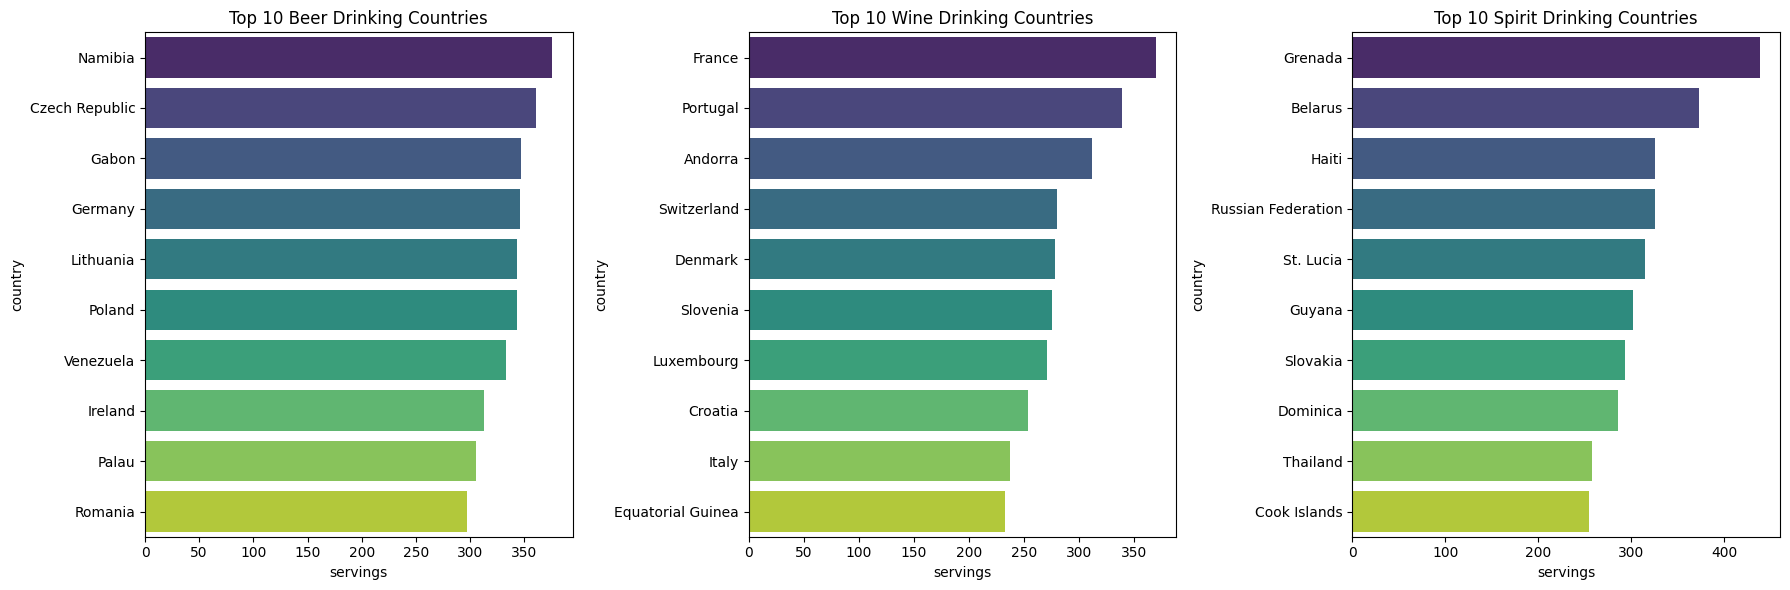

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns


tidy['drink'] = tidy['drink'].str.replace('_servings', '')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, drink in zip(axes, ['beer', 'wine', 'spirit']):
    data = tidy[tidy['drink'] == drink].sort_values('servings', ascending=False).head(10)
    sns.barplot(data=data, x='servings', y='country', ax=ax, palette='viridis')
    ax.set_title(f'Top 10 {drink.capitalize()} Drinking Countries')

plt.tight_layout()
plt.show()

## Problem 3
Create a wide dataframe using `pivot_table` with the tidy dataframe from Problem 2

In [8]:
wide = tidy.pivot_table(index='country', columns='drink', values='servings')
print(wide.head())

drink         beer  spirit   wine
country                          
Afghanistan    0.0     0.0    0.0
Albania       89.0   132.0   54.0
Algeria       25.0     0.0   14.0
Andorra      245.0   138.0  312.0
Angola       217.0    57.0   45.0
